In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from sklearn.linear_model import Ridge
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import LinearSVC,SVC
from sklearn.metrics import f1_score,make_scorer

from project_package.visualization import Model_Visualizer
from project_package import utility,evaluation

g:\Python\envs\learning_env\lib\site-packages\dask\dataframe\__init__.py:42: FutureWarning: 
Dask dataframe query planning is disabled because dask-expr is not installed.

You can install it with `pip install dask[dataframe]` or `conda install dask`.
This will raise in a future version.

  warnings.warn(msg, FutureWarning)


Regression test

In [2]:
test_data = utility.generate_data('diabetes',0.2,seed=0)
X_train, X_test, y_train, y_test = utility.generate_data('diabetes',0.2,seed=0,binary_label=True) 

In [3]:
vis_obj = Model_Visualizer(*test_data)
ridge = Ridge(alpha=1).fit(X_train, y_train)

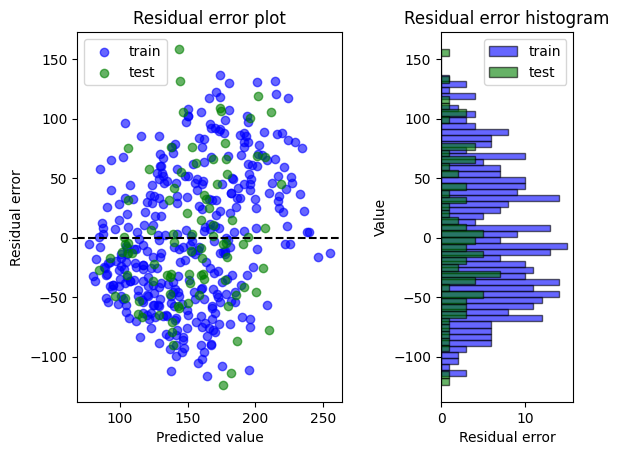

In [4]:
vis_obj.residual_plot(ridge,bins=50)

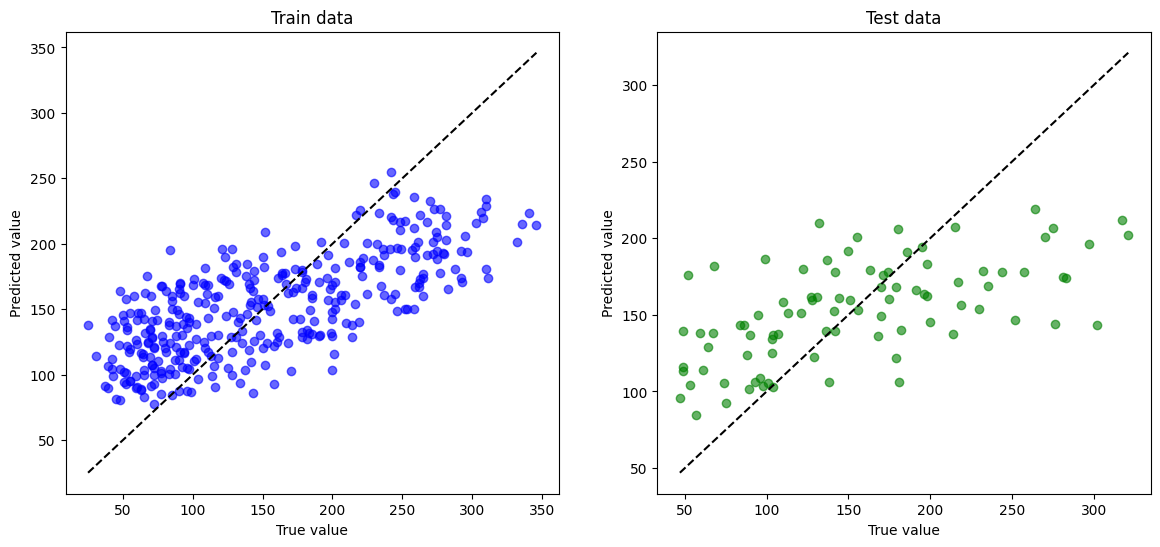

In [5]:
vis_obj.prediction_validate_plot(ridge)

Classification test

In [6]:
test_data = utility.generate_data('cancer',0.3,seed=0,binary_label=True,add_random=False)
X_train, X_test, y_train, y_test = utility.generate_data('cancer',0.3,seed=0,binary_label=True,add_random=False) 
feature_labels = utility.get_feature_labels('cancer')
vis_obj = Model_Visualizer(*test_data,feature_names=feature_labels)

In [7]:
# classifier = make_pipeline(StandardScaler(), LinearSVC(random_state=0))
classifier = make_pipeline(StandardScaler(), SVC(random_state=0))
# classifier = SVC(kernel='linear',random_state=0,probability=True)
# classifier = LinearSVC(random_state=0)
classifier.fit(X_train,y_train)

Pipeline(steps=[('standardscaler', StandardScaler()),
                ('svc', SVC(random_state=0))])

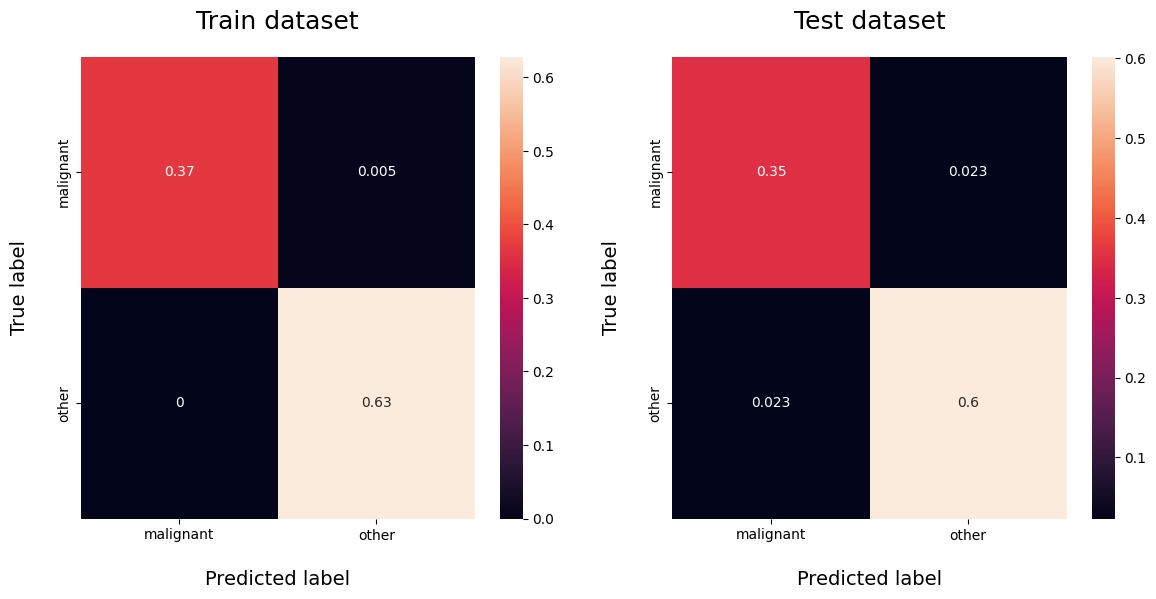

In [8]:
vis_obj.confusion_matrix(classifier,utility.get_target_labels('cancer',binary_label=True),normalize=True)

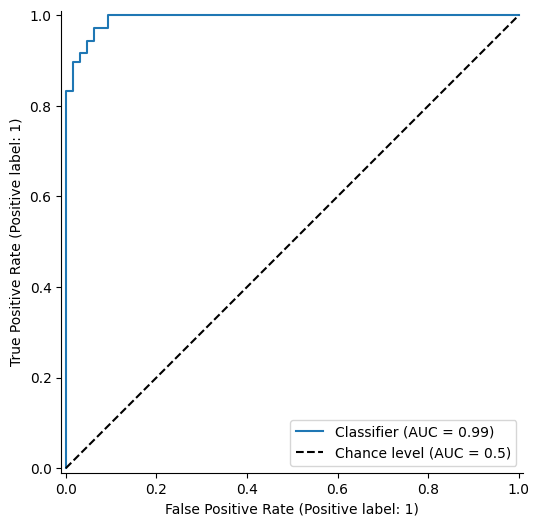

In [9]:
vis_obj.ROC_curve(y_test = y_test,y_score = classifier.decision_function(X_test))

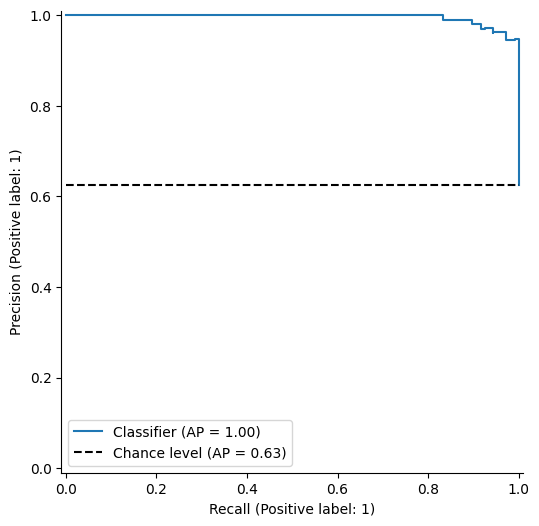

In [10]:
vis_obj.precision_recall_curve(y_test = y_test,y_score = classifier.decision_function(X_test))
plt.show()

Feature Importance and Ablation Analysis

In [12]:
vis_obj.feature_importance_plot(classifier.named_steps['linearsvc'].coef_[0],normalize=False,top_n=10)

KeyError: 'linearsvc'

In [11]:
train_data,test_data = vis_obj.reconstruct_dataframe()

In [12]:
train_permute,test_permute = evaluation.permutation_test(classifier,train_data,test_data,target_col = 'target_variable',scorer='f1_macro')

<Axes: title={'center': 'train data'}, xlabel='Decrease in metric score'>

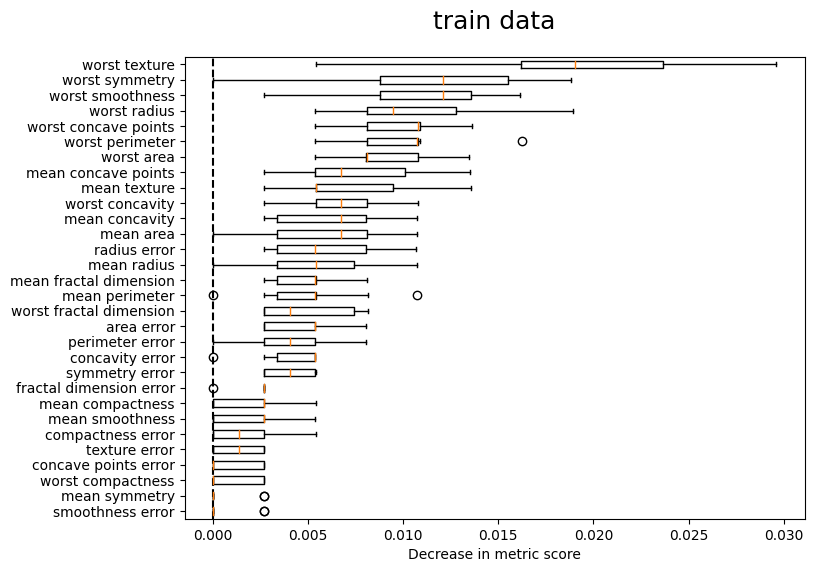

In [13]:
vis_obj.permutation_importance_plot(train_permute,figsize=(8,6),title='train data')

<Axes: title={'center': 'test data'}, xlabel='Decrease in metric score'>

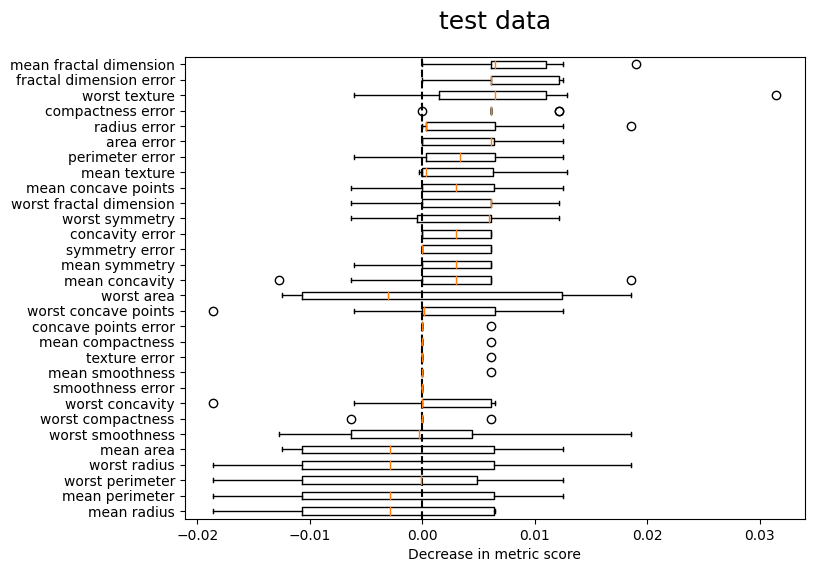

In [14]:
vis_obj.permutation_importance_plot(test_permute,figsize=(8,6),title='test data')

<Axes: title={'center': 'Ablation test'}, xlabel='f1 score'>

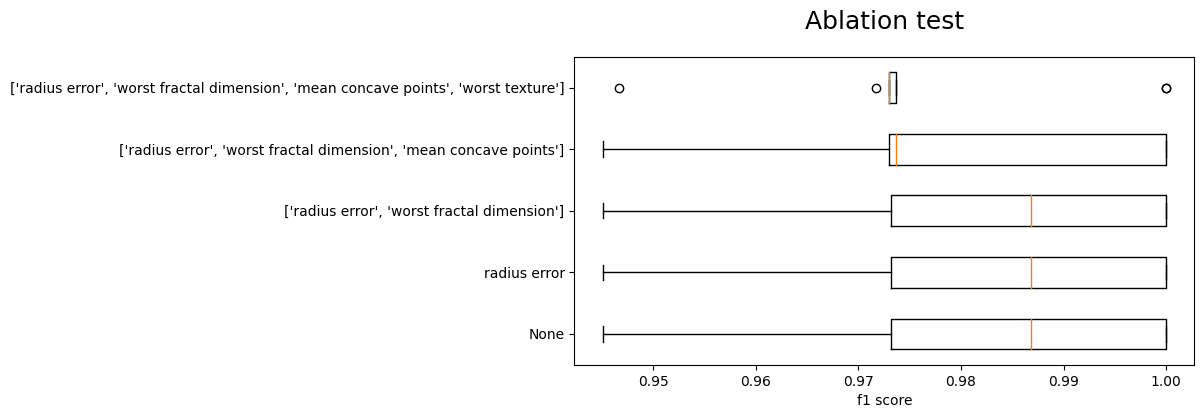

In [15]:
remove_features = ['radius error',
                    ['radius error','worst fractal dimension'],
                    ['radius error','worst fractal dimension','mean concave points'],
                    ['radius error','worst fractal dimension','mean concave points','worst texture']
                    ]

score_array,eval_df = evaluation.ablation_test(
    classifier,
    train_data = train_data,
    test_data = test_data,
    target_col = 'target_variable',
    scorer=make_scorer(f1_score,average='macro'),
    remove_features = remove_features
)

vis_obj.box_plot(score_array.T,labels=['None'] + remove_features,title='Ablation test',xlabel='f1 score')

Sensitivity Analysis

In [19]:
grids = {'linearsvc__C':np.logspace(1,5,10),'linearsvc__tol':np.logspace(-4,-3,10)}
evaluation.sensivity_test(
    classifier,train_data,
    target_col='target_variable',
    param_grid=grids,
    scoring={'r2':'r2','f1_macro':'f1_macro'}
    )

,linearsvc__C,linearsvc__tol,r2,f1_macro
0,10.0,0.000100,0.775048,0.944475
1,10.0,0.000129,0.775048,0.944475
2,10.0,0.000167,0.775048,0.944475
3,10.0,0.000215,0.775048,0.944475
4,10.0,0.000278,0.775048,0.944475
...,...,...,...,...
95,100000.0,0.000359,0.753714,0.939271
96,100000.0,0.000464,0.753714,0.939271
97,100000.0,0.000599,0.753714,0.939271
98,100000.0,0.000774,0.753714,0.939271


In [57]:
np.logspace(-3,6,10)

array([1.e-03, 1.e-02, 1.e-01, 1.e+00, 1.e+01, 1.e+02, 1.e+03, 1.e+04,
       1.e+05, 1.e+06])

In [58]:
grids = {'svc__C':np.logspace(-3,6,10),'svc__gamma':np.logspace(-4,7,12)}
# grids = {'svc__C':np.linspace(0.01,1000,15),'svc__gamma':np.linspace(0.01,1000,10)}
eval_df = evaluation.sensivity_test(
    classifier,train_data,
    target_col='target_variable',
    param_grid=grids,
    # scoring={'r2':'r2','f1_macro':'f1_macro'}
    scoring = 'f1_macro'
    )
eval_df

,svc__C,svc__gamma,score,score_std
0,0.001,1.000000e-04,0.385817,0.002404
1,0.001,1.000000e-03,0.385817,0.002404
2,0.001,1.000000e-02,0.385817,0.002404
3,0.001,1.000000e-01,0.385817,0.002404
4,0.001,1.000000e+00,0.385817,0.002404
...,...,...,...,...
115,1000000.000,1.000000e+03,0.385817,0.002404
116,1000000.000,1.000000e+04,0.385817,0.002404
117,1000000.000,1.000000e+05,0.385817,0.002404
118,1000000.000,1.000000e+06,0.385817,0.002404


In [97]:
x1,x2 = np.meshgrid(np.linspace(0.01,1000,15),np.linspace(0.01,1000,10))
x2.shape
test_df = eval_df.pivot(index='svc__C', columns='svc__gamma', values='score')
test_df.values.shape

(15, 10)

In [62]:
test_df = eval_df.loc[eval_df.svc__C==1]
test_df

,svc__C,svc__gamma,score,score_std
36,1.0,1.000000e-04,0.667130,0.072084
37,1.0,1.000000e-03,0.944709,0.027746
38,1.0,1.000000e-02,0.972732,0.021079
39,1.0,1.000000e-01,0.968241,0.030930
40,1.0,1.000000e+00,0.385817,0.002404
41,1.0,1.000000e+01,0.385817,0.002404
42,1.0,1.000000e+02,0.385817,0.002404
43,1.0,1.000000e+03,0.385817,0.002404
44,1.0,1.000000e+04,0.385817,0.002404
45,1.0,1.000000e+05,0.385817,0.002404


In [ ]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots

def sensivity_plot(
        data,
        param1=None,  #(name,filter_col,1) or name
        param2=None,
        plot_3d_grid = True,
        log_params = True,
        subplot_titles=("First Subplot","Second Subplot", "Third Subplot"),
        width=1200,
        height=1000
        
    ):

    if param1 is None and param2 is None:
        return go.Figure()

    n = len(set([param1,param2]))

    if type(param1)==dict:
        graph1_df = data.loc[data[param1[1]]==param1[-1]]
    else:
        graph1_df = data

    if type(param2)==dict:
        graph2_df = data.loc[data[param2[1]]==param2[-1]]
    else:
        graph2_df = data

    if param1 and n==1:
        pass

    if param2 and n==1:
        pass

    if n==2:
        fig = make_subplots(
            rows=2, cols=2,
            specs=[[{}, {}],
                [{"colspan": 2}, None]],
            subplot_titles=subplot_titles
        )
        
        # subplot 1: first parameter



    if log_params and plot_3d_grid:
        fig.update_xaxes(type="log")
        fig.update_yaxes(type="log")
    elif log_params:
        fig.update_xaxes(type="log")

    fig.update_layout(
        width=width,
        height=height
    )
    return fig

fig = make_subplots(
    rows=2, cols=2,
    specs=[[{}, {}],
           [{"colspan": 2}, None]],
    subplot_titles=("First Subplot","Second Subplot", "Third Subplot"))


# fig.add_trace(
#     go.Scatter(
#         x=[1, 2, 3, 4], y=[3, 4, 8, 3],
#         fill=None,
#         mode='lines',
#         line_color='indigo'
#         ),
#     row=1, col=1
#     )
# fig.add_trace(
#     go.Scatter(
#         x=[1, 2, 3, 4],
#         y=[1, 6, 2, 6],
#         fill='tonexty', # fill area between trace0 and trace1
#         mode='lines', line_color='indigo'),
#         row=1, col=1
#     )
# fig

fig.add_trace(
    go.Scatter(
        x=test_df.svc__gamma, y=test_df.score-test_df.score_std,
        fill=None,
        mode='lines',
        line_color='indigo'
        ),
    row=1, col=1
    )
fig.add_trace(
    go.Scatter(
        x=test_df.svc__gamma, y=test_df.score+test_df.score_std,
        fill='tonexty', # fill area between trace0 and trace1
        mode='lines', line_color='indigo'),
        row=1, col=1
    )

fig.add_trace(
    go.Scatter(
        x=test_df.svc__gamma, y=test_df.score,
        fill=None, # fill area between trace0 and trace1
        mode='lines', line_color='red'),
        row=1, col=1
    )
fig.update_xaxes(type="log")
fig.update_layout(
    width=1200,  # wider
    height=1000,  # taller
    # title="Larger Subplot Layout"
)


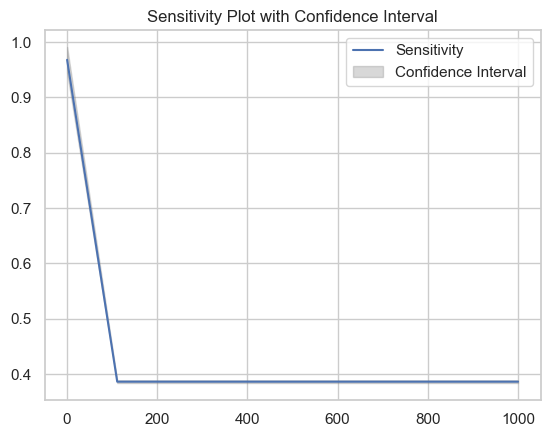

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

fig,ax = plt.subplots()
ax.plot(test_df.svc__gamma, test_df.score, label="Sensitivity")
ax.fill_between(
    test_df.svc__gamma, 
    test_df.score-test_df.score_std, 
    test_df.score+test_df.score_std, 
    color='gray', 
    alpha=0.3, 
    label="Confidence Interval"
    )
ax.legend()
ax.set_title("Sensitivity Plot with Confidence Interval")

ax.set_title("Sensitivity Plot with Confidence Interval", fontsize=18, pad=20)
ax.set_xlabel(xlabel)
plt.show()

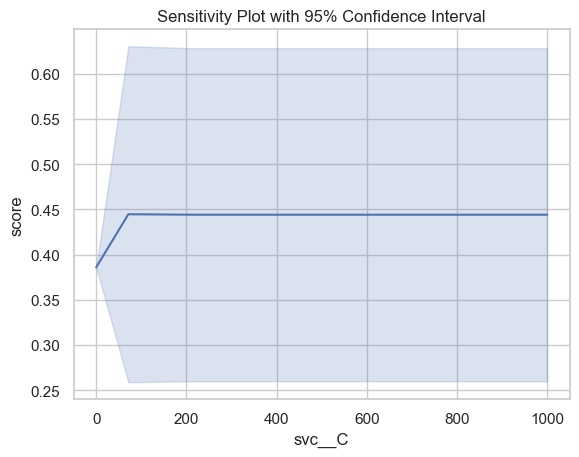

In [43]:
import seaborn as sns
import matplotlib.pyplot as plt

# Sample data
sns.set(style="whitegrid")
data = sns.load_dataset("flights")

# Sensitivity plot with 95% confidence interval
sns.lineplot(data=eval_df, x="svc__C", y="score", errorbar="sd")
plt.title("Sensitivity Plot with 95% Confidence Interval")
plt.show()

In [102]:
import plotly.graph_objects as go
import pandas as pd
import numpy as np

# x = np.logspace(-2,3,15)
# y = np.logspace(-2,3,15)
x = np.linspace(0.01,1000,15)  # C
y = np.linspace(0.01,1000,10)
z = eval_df.score.to_numpy().reshape((15,10)).T
fig = go.Figure(data=[go.Surface(z=z, x=x, y=y,hovertemplate="<b>C:</b> %{x}<br>" +
                  "<b>Gamma:</b> %{y}<br>" +
                  "<b>Score:</b> %{z}")])
fig.update_layout(title=dict(text='Mt Bruno Elevation'), autosize=False,
                  width=500, height=500,
                  margin=dict(l=65, r=50, b=65, t=90),scene_xaxis_title_text='C',scene_yaxis_title_text='gamma')
fig.show()

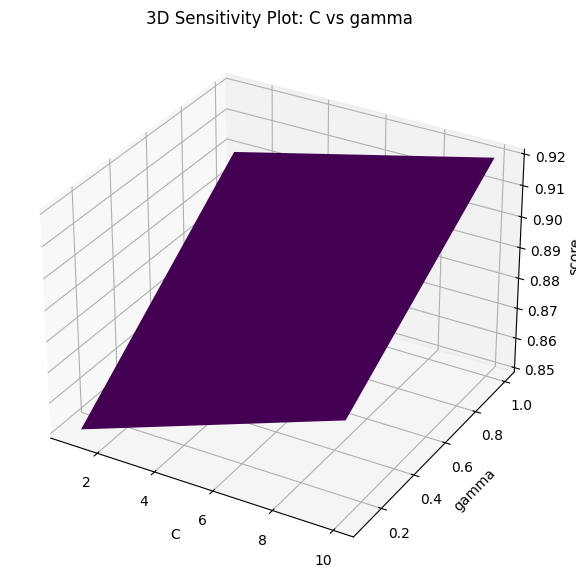

In [67]:
import pandas as pd

df = pd.DataFrame({
    'C': [1, 10, 1, 10],
    'gamma': [0.1, 0.1, 1, 1],
    'score': [0.85, 0.88, 0.90, 0.92]
})  
pivot = df.pivot(index='gamma', columns='C', values='score')
pivot
import numpy as np

X, Y = np.meshgrid(pivot.columns.values, pivot.index.values)
Z = pivot.values  # This is your score matrix

import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')
ax.plot_surface(X, Y, Z, cmap='viridis')

ax.set_xlabel('C')
ax.set_ylabel('gamma')
ax.set_zlabel('score')
plt.title('3D Sensitivity Plot: C vs gamma')
plt.show()

In [34]:
from sklearn import svm, datasets
from sklearn.model_selection import GridSearchCV
iris = datasets.load_iris()
parameters = {'kernel':('linear', 'rbf'), 'C':[1, 10]}
svc = svm.SVC()
clf = GridSearchCV(svc, parameters,cv=7,scoring='f1_macro',verbose=0)
clf.fit(iris.data, iris.target)
sorted(clf.cv_results_.keys())

['mean_fit_time',
 'mean_score_time',
 'mean_test_score',
 'param_C',
 'param_kernel',
 'params',
 'rank_test_score',
 'split0_test_score',
 'split1_test_score',
 'split2_test_score',
 'split3_test_score',
 'split4_test_score',
 'split5_test_score',
 'split6_test_score',
 'std_fit_time',
 'std_score_time',
 'std_test_score']

testing pycaret

In [10]:
from pycaret import regression
from pycaret import classification
from sklearn import datasets
import plotly.express as px
from sklearn.model_selection import train_test_split
import numpy as np

In [160]:
data = px.data.iris()
data.drop('species_id',axis=1,inplace=True)

In [161]:
train_idx,test_idx = train_test_split(np.arange(data.shape[0]),test_size=0.3,stratify=data.species,random_state=0)

In [162]:
train_data = data.iloc[train_idx].reset_index(drop=True)
test_data = data.iloc[test_idx].reset_index(drop=True)

In [ ]:
classification.get_config('dataset_transformed')

,sepal_length,sepal_width,petal_length,petal_width,species
0,0.975431,0.569896,1.080800,1.703073,2
1,2.141950,1.673939,1.637094,1.310056,2
2,0.625476,0.349088,0.858283,1.441062,2
3,-1.474257,1.232322,-1.533783,-1.310056,0
4,-0.774346,0.790705,-1.311265,-1.310056,0
...,...,...,...,...,...
145,-0.424390,1.011514,-1.366894,-1.310056,0
146,1.558691,1.232322,1.303318,1.703073,2
147,-1.474257,0.128279,-1.255635,-1.310056,0
148,-1.240953,-0.092529,-1.311265,-1.441062,0


In [172]:
classification.setup(data=train_data, target='species',test_data=test_data,index=False,normalize=False,fold=4)

,Description,Value
0,Session id,2568
1,Target,species
2,Target type,Multiclass
3,Target mapping,"setosa: 0, versicolor: 1, virginica: 2"
4,Original data shape,"(150, 5)"
5,Transformed data shape,"(150, 5)"
6,Transformed train set shape,"(105, 5)"
7,Transformed test set shape,"(45, 5)"
8,Numeric features,4
9,Preprocess,True


In [194]:
# custom_model = classification.create_model(LinearSVC())
custom_model = classification.create_model(classifier)

,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,1.0000,0.0000,1.0000,1.0000,1.0000,1.0000,1.0000
1,0.9231,0.0000,0.9231,0.9231,0.9231,0.8844,0.8844
2,1.0000,0.0000,1.0000,1.0000,1.0000,1.0000,1.0000
3,0.9615,0.0000,0.9615,0.9654,0.9613,0.9421,0.9442
Mean,0.9712,0.0000,0.9712,0.9721,0.9711,0.9566,0.9572
Std,0.0319,0.0000,0.0319,0.0316,0.0319,0.0479,0.0478


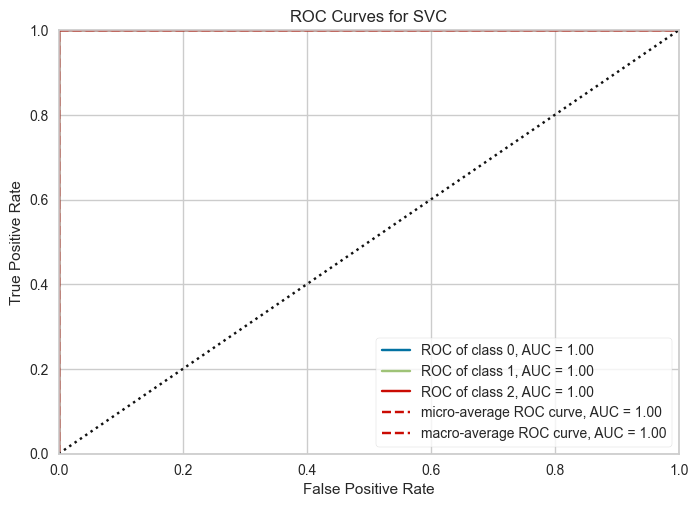

In [195]:
classification.plot_model(custom_model, plot='auc')